In [52]:
import sys
from pathlib import Path

# Allow imports from project root
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.config import CONFIG, PROJECT_ROOT

# Plotting config
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COLORS = {
    "aaa_spread": "#1b9e77",
    "aa_spread":  "#7570b3",
    "bbb_spread": "#d95f02",
    "hy_spread":  "#e7298a",
    "vix":        "#666666",
}

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

In [53]:
df = pd.read_csv(
    PROJECT_ROOT / "data/processed/master_enriched.csv",
    index_col=0, parse_dates=True,
)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

Shape: (6803, 50)
Date range: 2000-06-23 to 2026-03-19


,aaa_spread,aa_spread,bbb_spread,hy_spread,treasury_10y,treasury_5y,vix,aaa_spread_change_1d,aaa_spread_change_5d,aaa_spread_change_20d,...,hy_spread_zscore_60d,hy_spread_zscore_252d,hy_spread_zscore_ema_60d,hy_spread_zscore_ema_252d,hy_spread_pctile_252d,hy_spread_rolling_vol_20d,hy_spread_rolling_vol_60d,bbb_hy_ratio,bbb_hy_ratio_change_1d,aa_bbb_ratio
date,,,,,,,,,,,,,,,,,,,,,
2000-06-23,0.99,1.23,2.13,5.99,6.19,6.37,22.34,-0.01,-0.01,0.00,...,0.215035,0.987132,0.196709,0.752092,0.410714,0.040324,0.056561,0.355593,0.002457,0.577465
2000-06-26,1.00,1.24,2.14,6.05,6.11,6.29,22.45,0.01,0.00,0.00,...,0.557818,1.092657,0.371517,0.862835,0.420635,0.043054,0.053190,0.353719,-0.001874,0.579439
2000-06-27,0.98,1.24,2.15,6.05,6.10,6.29,21.80,-0.02,-0.03,-0.02,...,0.545631,1.083334,0.364440,0.853535,0.422619,0.042364,0.053190,0.355372,0.001653,0.576744
2000-06-28,0.98,1.24,2.15,6.04,6.11,6.28,20.29,0.00,-0.02,-0.04,...,0.470243,1.055421,0.327007,0.824735,0.420635,0.042227,0.052360,0.355960,0.000588,0.576744
2000-06-29,0.98,1.25,2.14,6.11,6.04,6.21,19.70,0.00,-0.02,-0.05,...,0.857398,1.178434,0.537071,0.954357,0.440476,0.043100,0.052972,0.350245,-0.005715,0.584112


In [54]:
def add_crisis_bands(ax, crisis_periods):
    """Add shaded crisis periods to a matplotlib axis."""
    for i, cp in enumerate(crisis_periods):
        ax.axvspan(
            pd.Timestamp(cp["start"]), pd.Timestamp(cp["end"]),
            alpha=0.12, color="#999999",
            label=cp["name"] if i < 5 else None,  # avoid legend clutter
        )

crisis_periods = CONFIG["crisis_periods"]

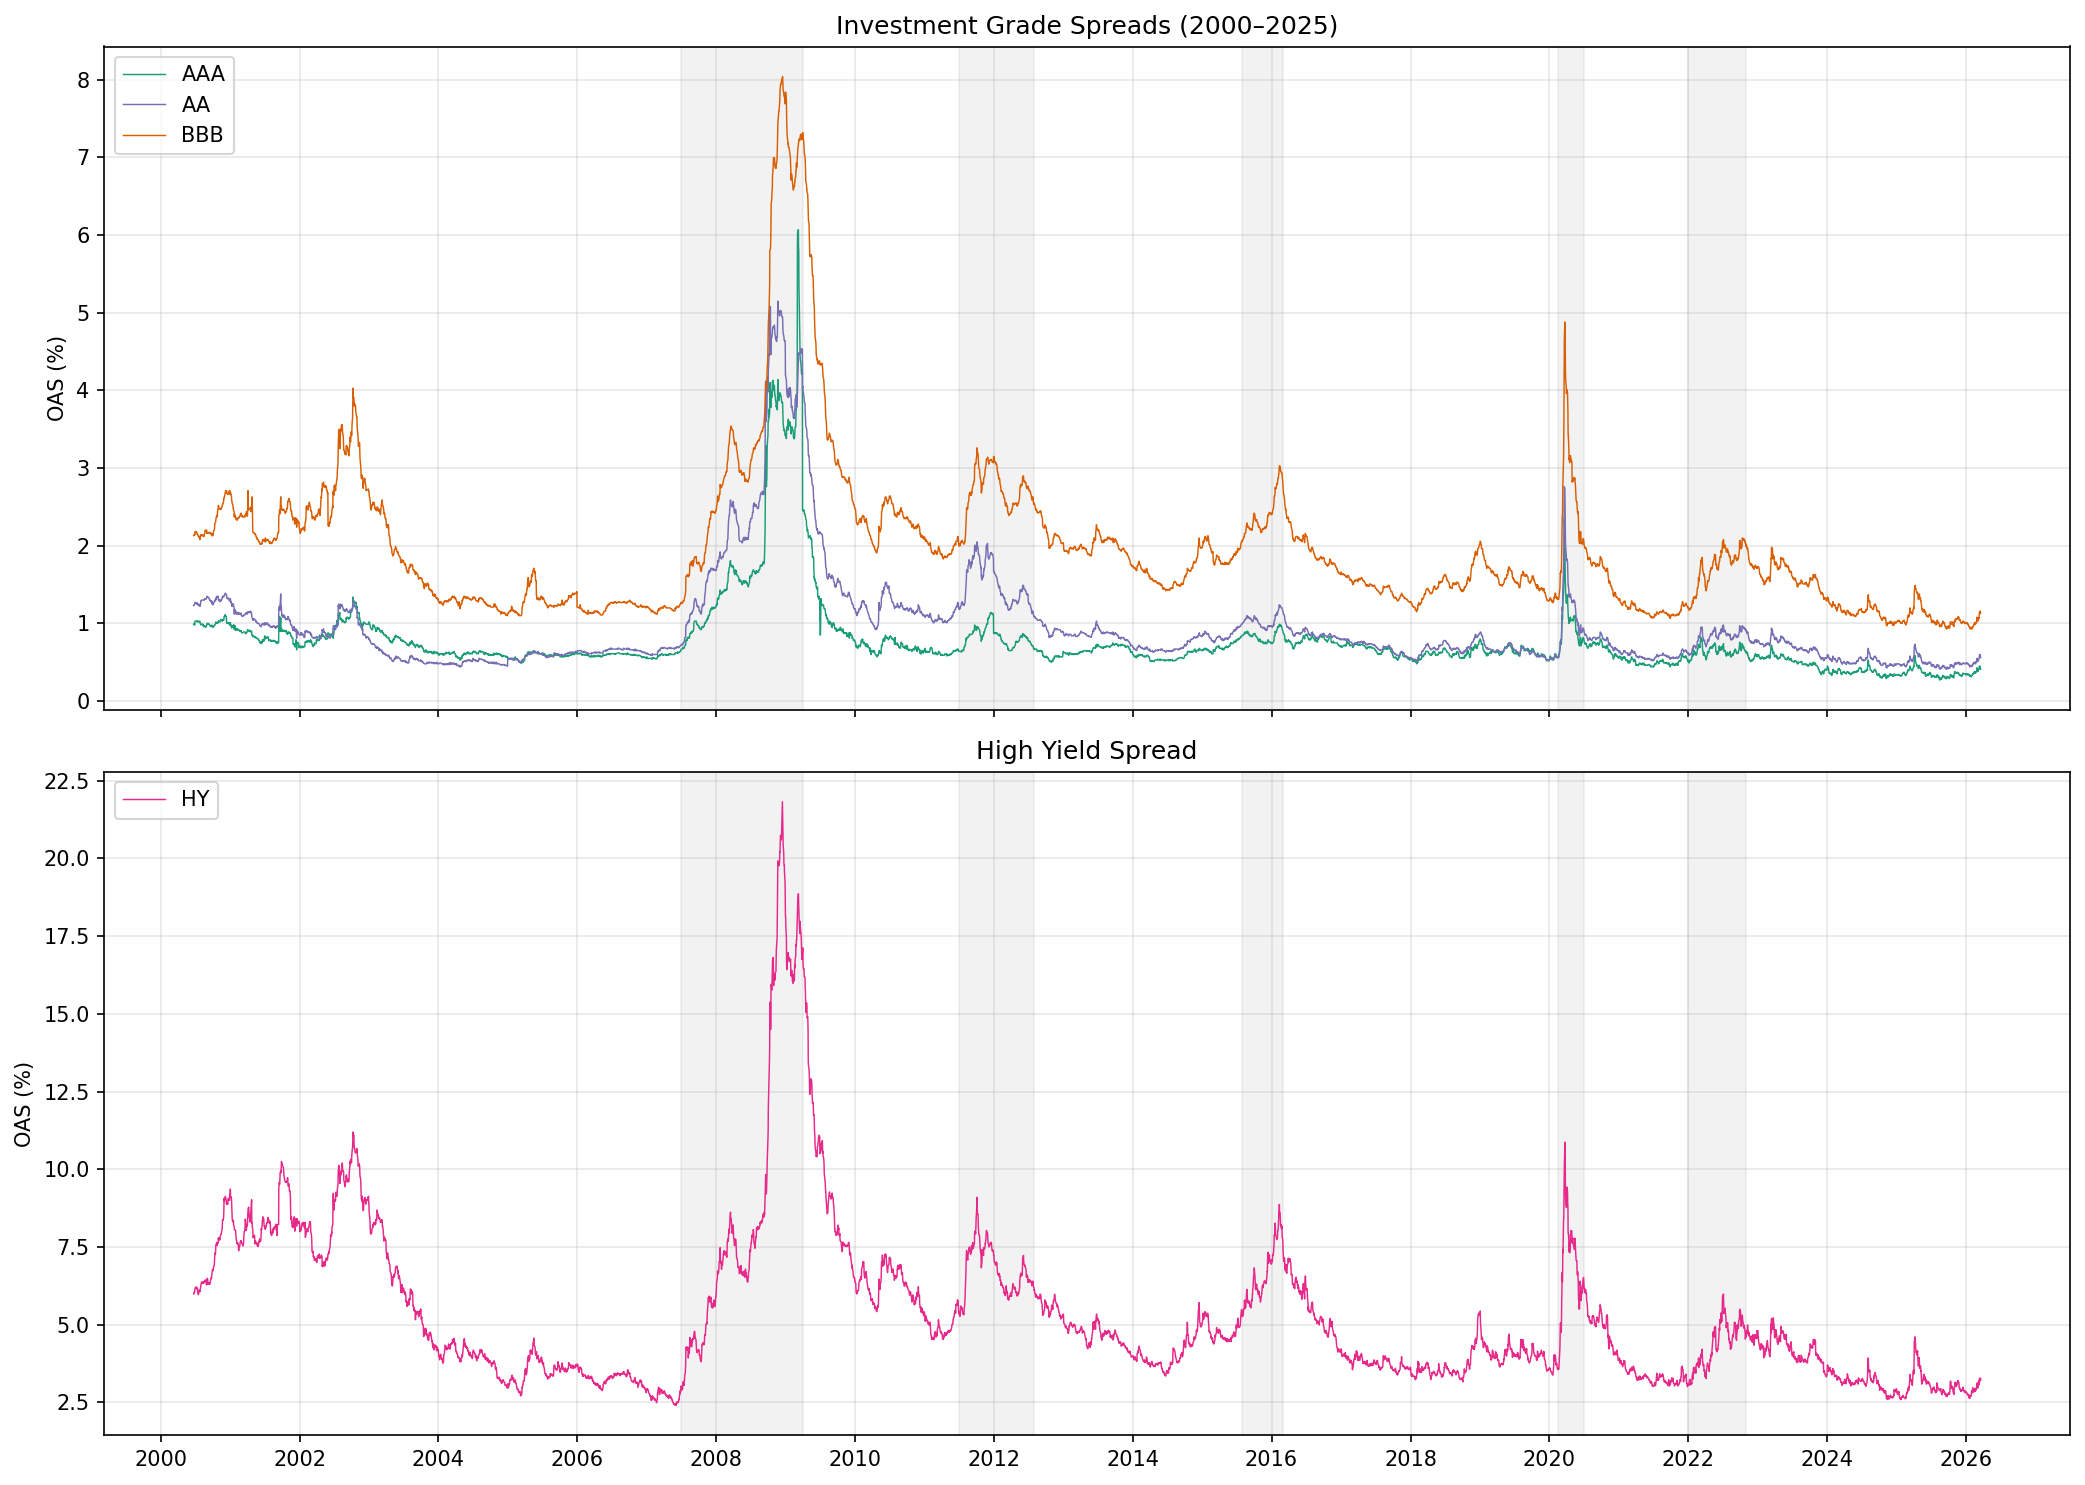

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top: IG spreads
ax1 = axes[0]
for col in ["aaa_spread", "aa_spread", "bbb_spread"]:
    ax1.plot(df.index, df[col], label=col.replace("_spread","").upper(),
             color=COLORS[col], linewidth=0.7)
ax1.set_ylabel("OAS (%)")
ax1.set_title("Investment Grade Spreads (2000–2025)")
ax1.legend(loc="upper left")

# Bottom: HY spread
ax2 = axes[1]
ax2.plot(df.index, df["hy_spread"], label="HY", color=COLORS["hy_spread"], linewidth=0.7)
ax2.set_ylabel("OAS (%)")
ax2.set_title("High Yield Spread")
ax2.legend(loc="upper left")
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


add_crisis_bands(ax1, crisis_periods)
add_crisis_bands(ax2, crisis_periods)


fig.tight_layout()
fig.savefig(FIGURES_DIR / "spread_history.png", bbox_inches="tight")
plt.show()

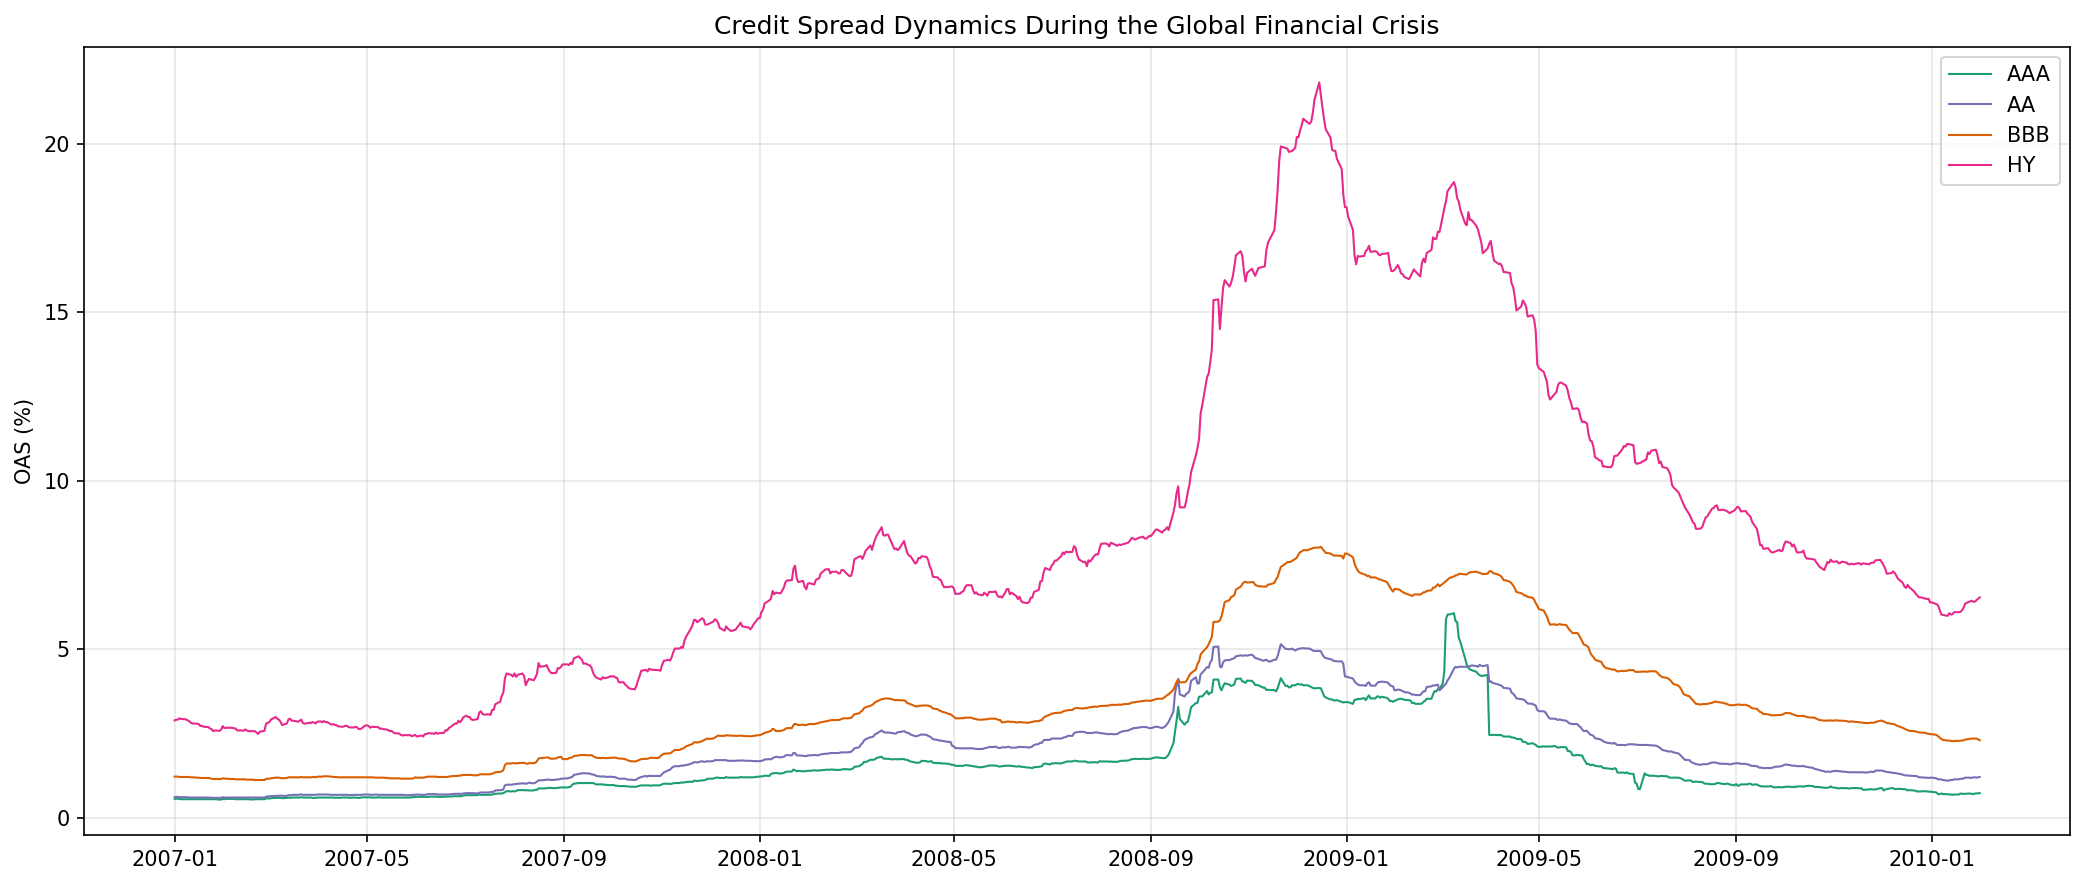

In [56]:
# Zoom GFC 2007-2010
gfc = df.loc["2007-01":"2010-01"]

fig, ax = plt.subplots(figsize=(14, 6))
for col in ["aaa_spread", "aa_spread", "bbb_spread", "hy_spread"]:
    ax.plot(gfc.index, gfc[col], label=col.replace("_spread","").upper(),
            color=COLORS[col], linewidth=1)
ax.set_ylabel("OAS (%)")
ax.set_title("Credit Spread Dynamics During the Global Financial Crisis")
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "spread_crisis_zoom.png", bbox_inches="tight")
plt.show()

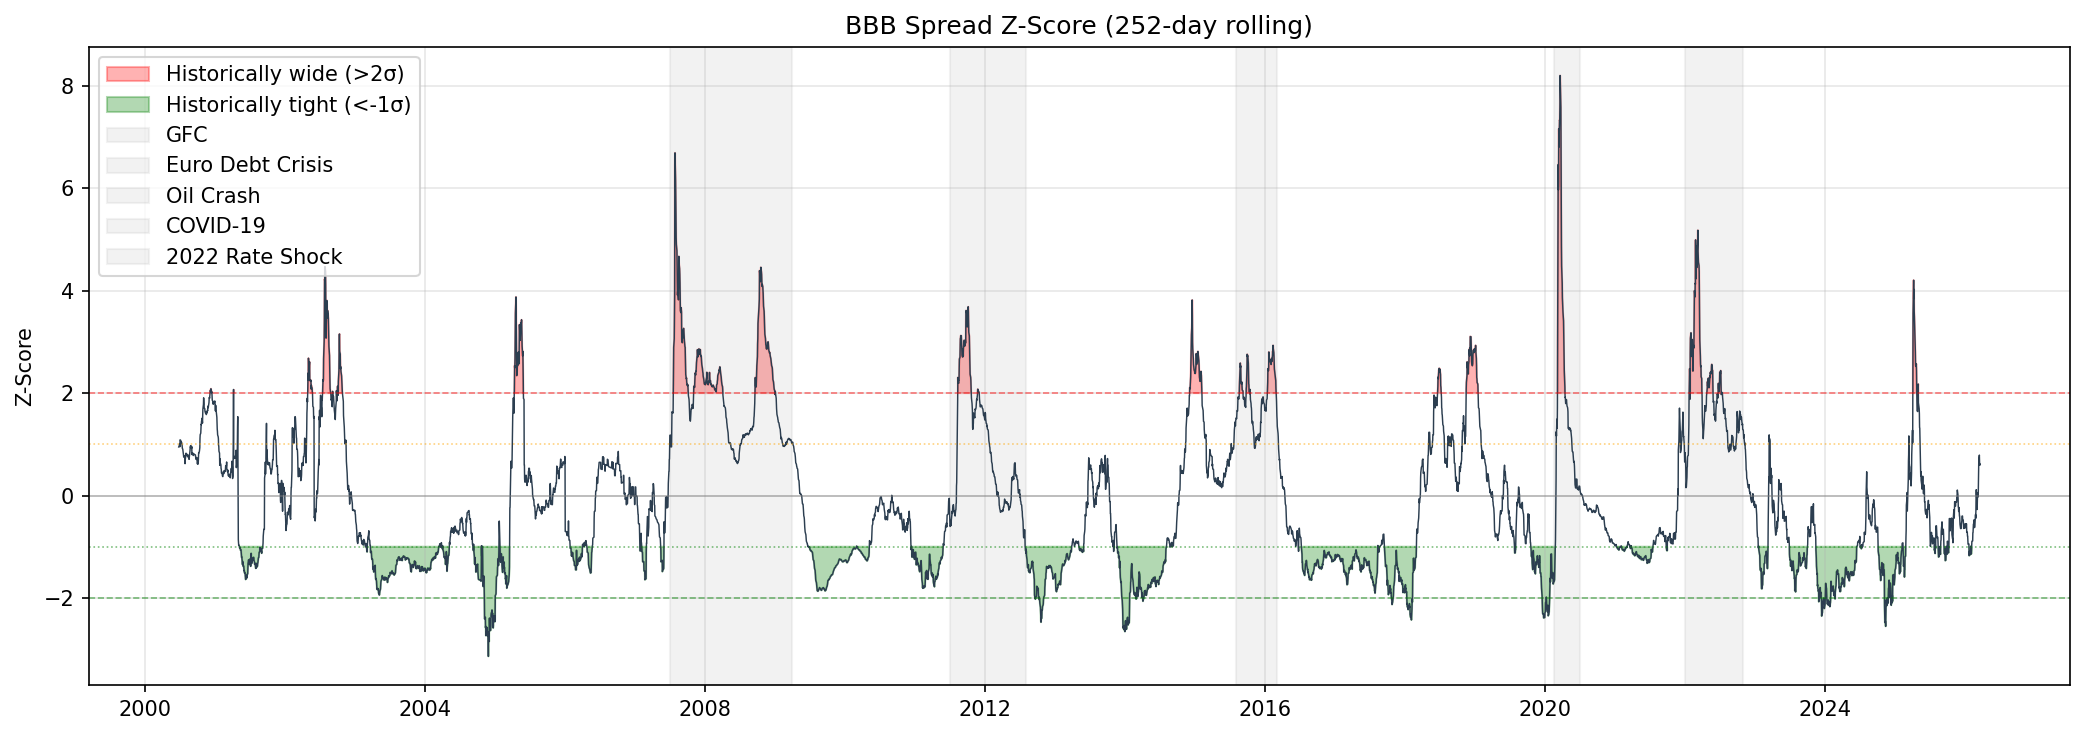

In [57]:
fig, ax = plt.subplots(figsize=(14, 5))

zscore_col = "bbb_spread_zscore_252d"
ax.plot(df.index, df[zscore_col], color="#2c3e50", linewidth=0.7)

# Threshold bands
for level, color, style in [(2, "red", "--"), (1, "orange", ":"),
                              (0, "gray", "-"),
                              (-1, "green", ":"), (-2, "green", "--")]:
    ax.axhline(level, color=color, linestyle=style, alpha=0.5, linewidth=0.8)

# Color fill
ax.fill_between(df.index, df[zscore_col], 2,
                where=df[zscore_col] > 2, alpha=0.3, color="red",
                label="Historically wide (>2σ)")
ax.fill_between(df.index, df[zscore_col], -1,
                where=df[zscore_col] < -1, alpha=0.3, color="green",
                label="Historically tight (<-1σ)")

add_crisis_bands(ax, crisis_periods)
ax.set_ylabel("Z-Score")
ax.set_title("BBB Spread Z-Score (252-day rolling)")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "zscore_bbb.png", bbox_inches="tight")
plt.show()

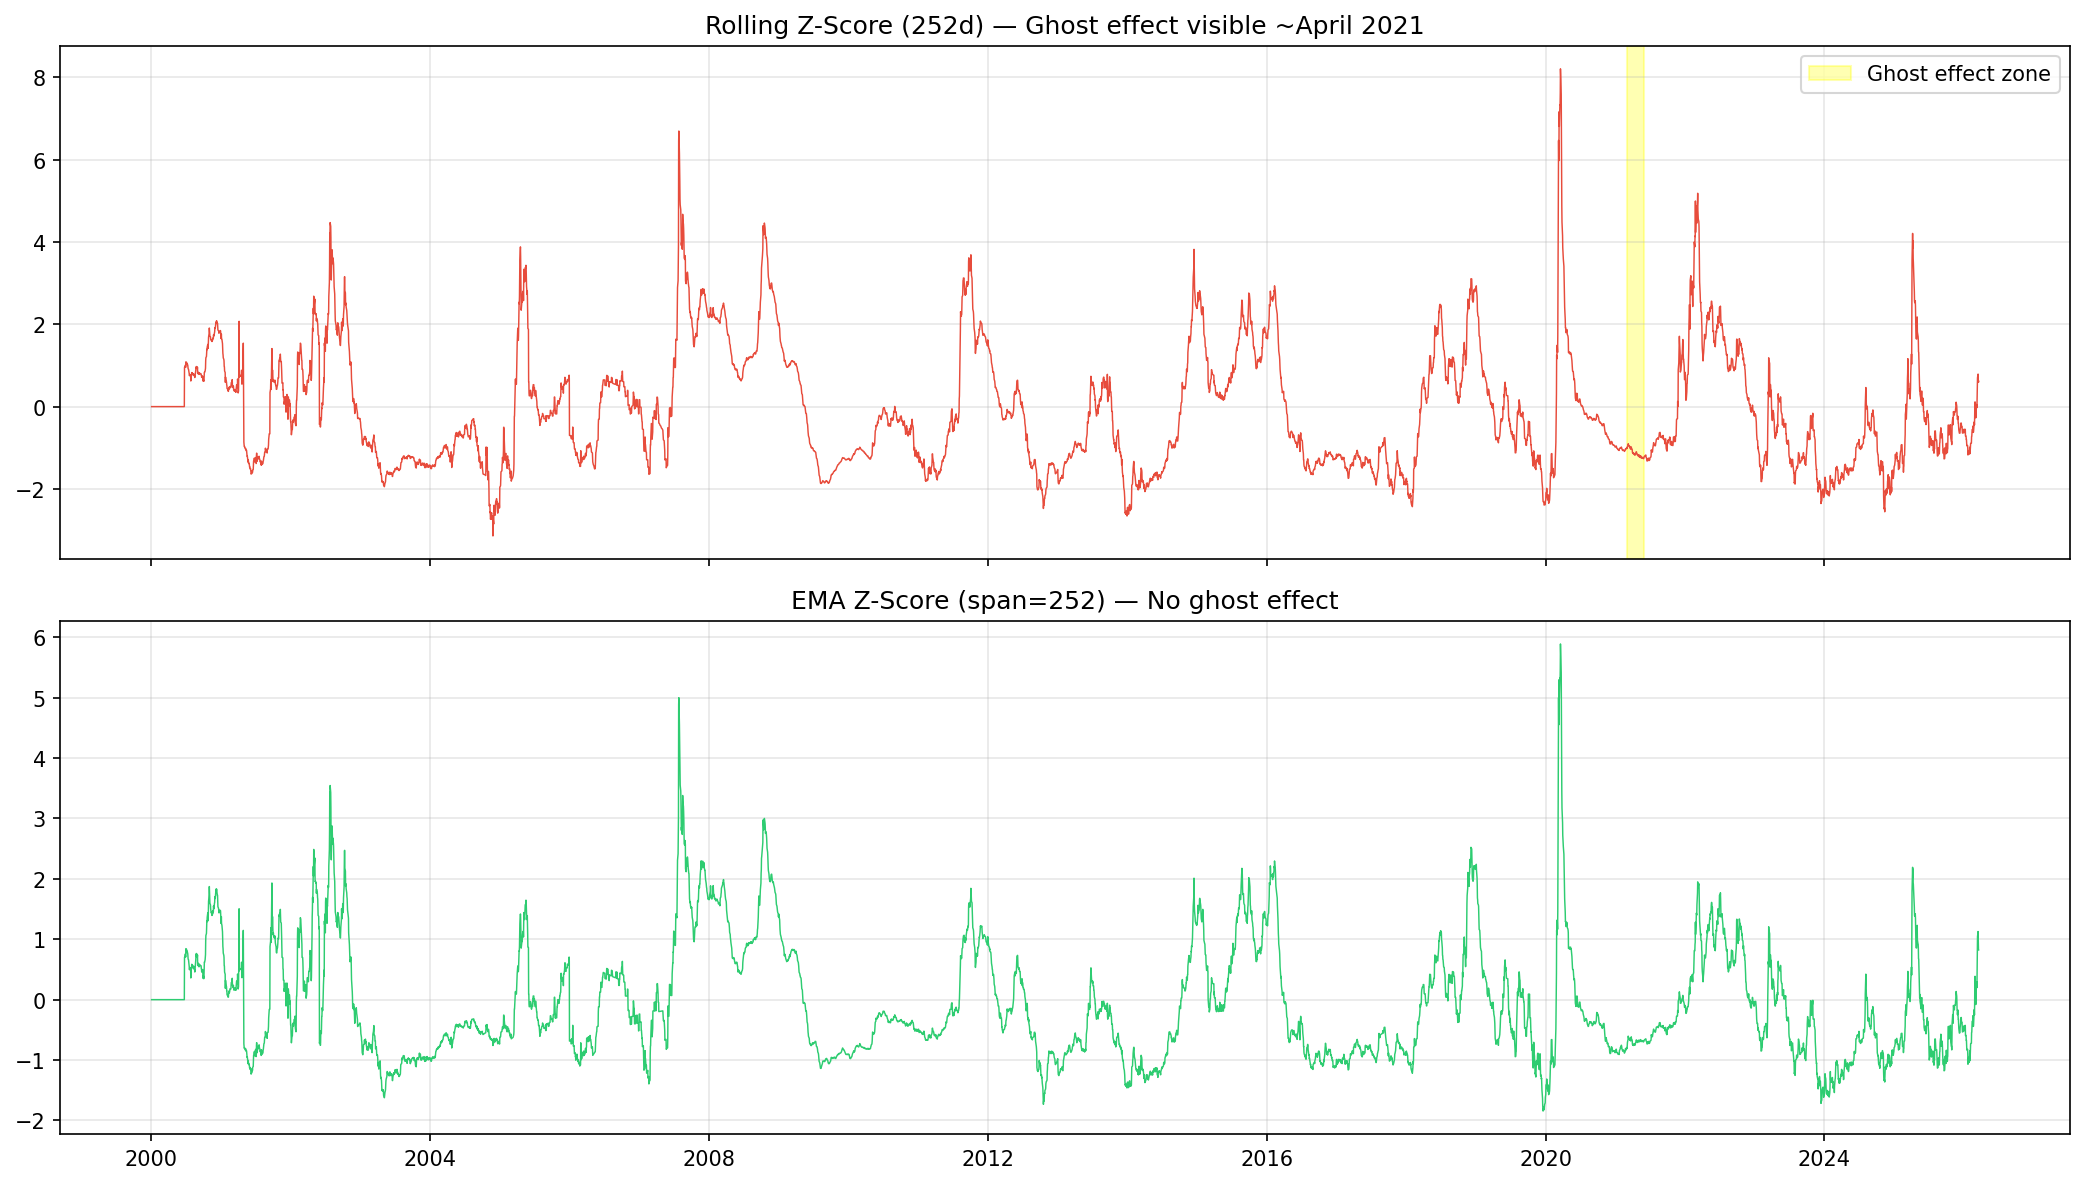

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Recompute with EMA for comparison
from src.features import compute_zscore, compute_zscore_ema

master = pd.read_csv(PROJECT_ROOT / "data/processed/master.csv",
                     index_col=0, parse_dates=True)

rolling_z = compute_zscore(master["bbb_spread"], 252)
ema_z = compute_zscore_ema(master["bbb_spread"], 252)

# Top: Rolling z-score with ghost effect visible
axes[0].plot(master.index, rolling_z, color="#e74c3c", linewidth=0.7)
axes[0].set_title("Rolling Z-Score (252d) — Ghost effect visible ~April 2021")
axes[0].axvspan("2021-03-01", "2021-06-01", alpha=0.3, color="yellow", label="Ghost effect zone")
axes[0].legend()

# Bottom: EMA z-score — smooth
axes[1].plot(master.index, ema_z, color="#2ecc71", linewidth=0.7)
axes[1].set_title("EMA Z-Score (span=252) — No ghost effect")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "zscore_ghost_effect_comparison.png", bbox_inches="tight")
plt.show()

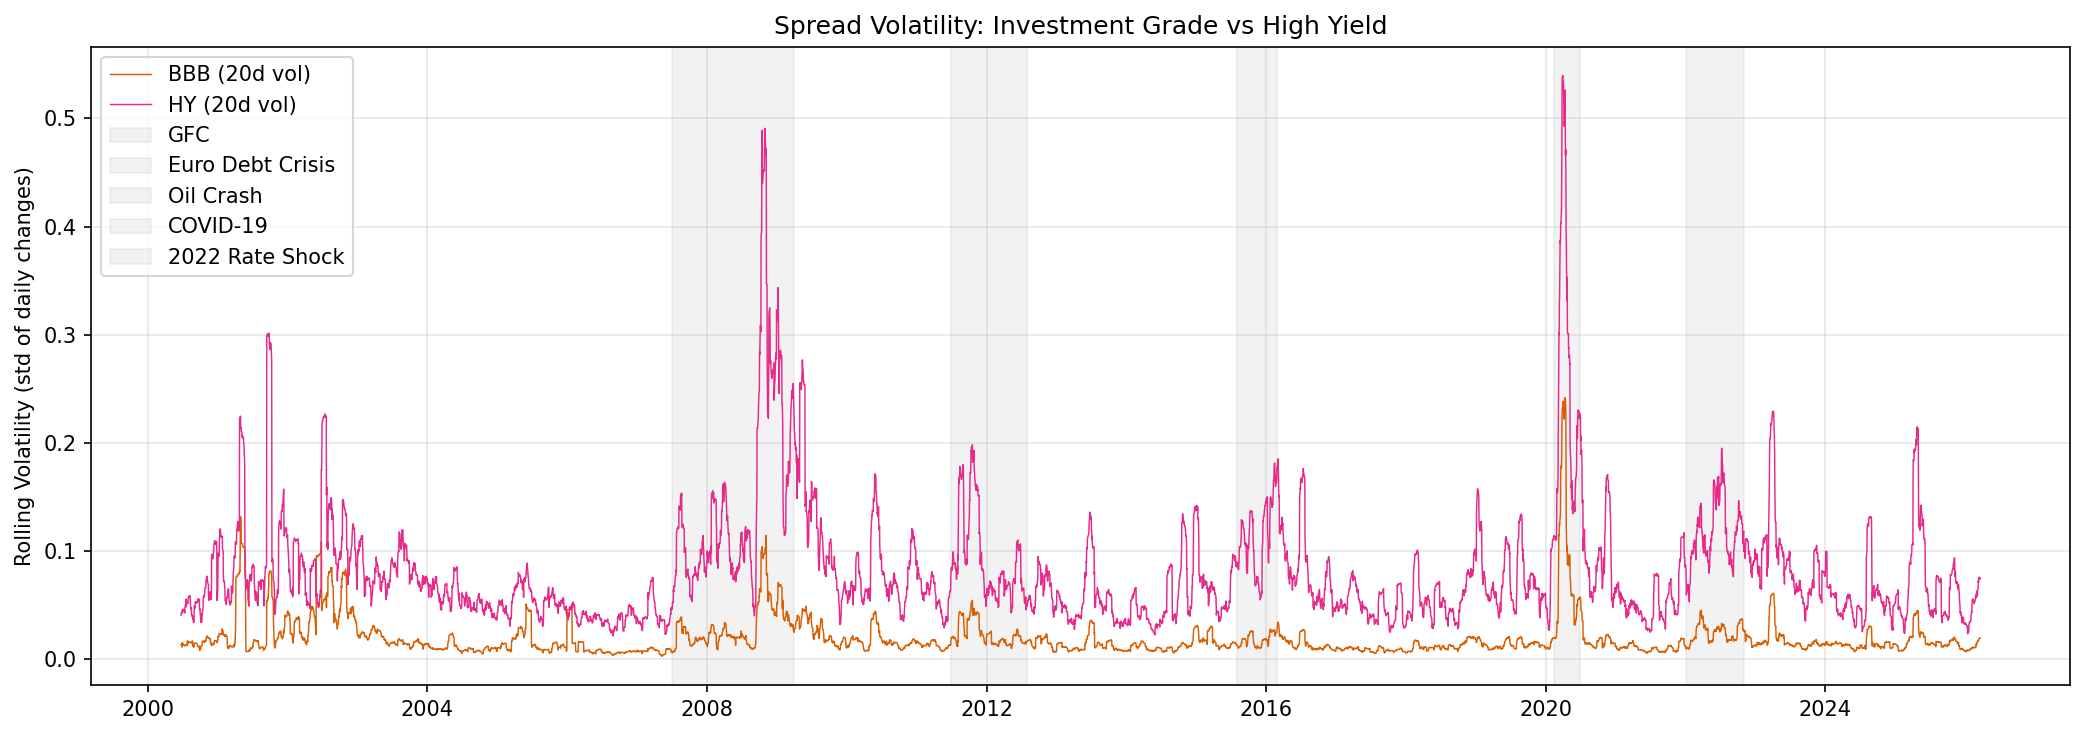

In [59]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["bbb_spread_rolling_vol_20d"],
        label="BBB (20d vol)", color=COLORS["bbb_spread"], linewidth=0.7)
ax.plot(df.index, df["hy_spread_rolling_vol_20d"],
        label="HY (20d vol)", color=COLORS["hy_spread"], linewidth=0.7)
add_crisis_bands(ax, crisis_periods)

ax.set_ylabel("Rolling Volatility (std of daily changes)")
ax.set_title("Spread Volatility: Investment Grade vs High Yield")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "volatility_comparison.png", bbox_inches="tight")
plt.show()

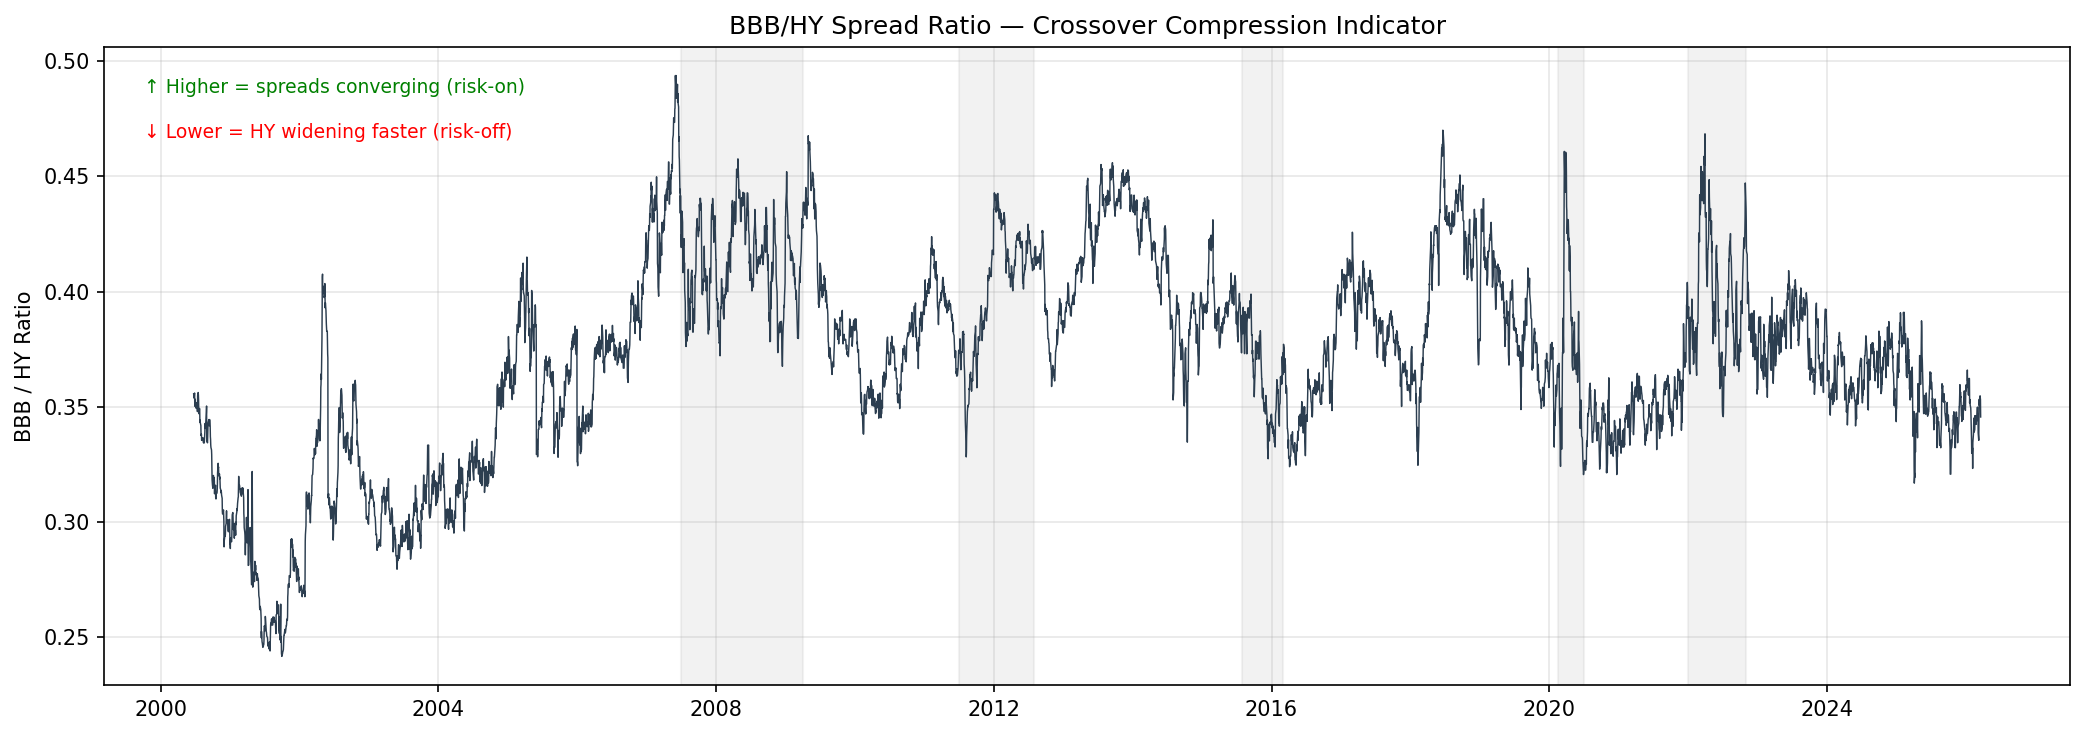

In [60]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["bbb_hy_ratio"], color="#2c3e50", linewidth=0.7)
add_crisis_bands(ax, crisis_periods)

ax.set_ylabel("BBB / HY Ratio")
ax.set_title("BBB/HY Spread Ratio — Crossover Compression Indicator")
ax.text(0.02, 0.95, "↑ Higher = spreads converging (risk-on)",
        transform=ax.transAxes, fontsize=9, va="top", color="green")
ax.text(0.02, 0.88, "↓ Lower = HY widening faster (risk-off)",
        transform=ax.transAxes, fontsize=9, va="top", color="red")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "bbb_hy_compression.png", bbox_inches="tight")
plt.show()

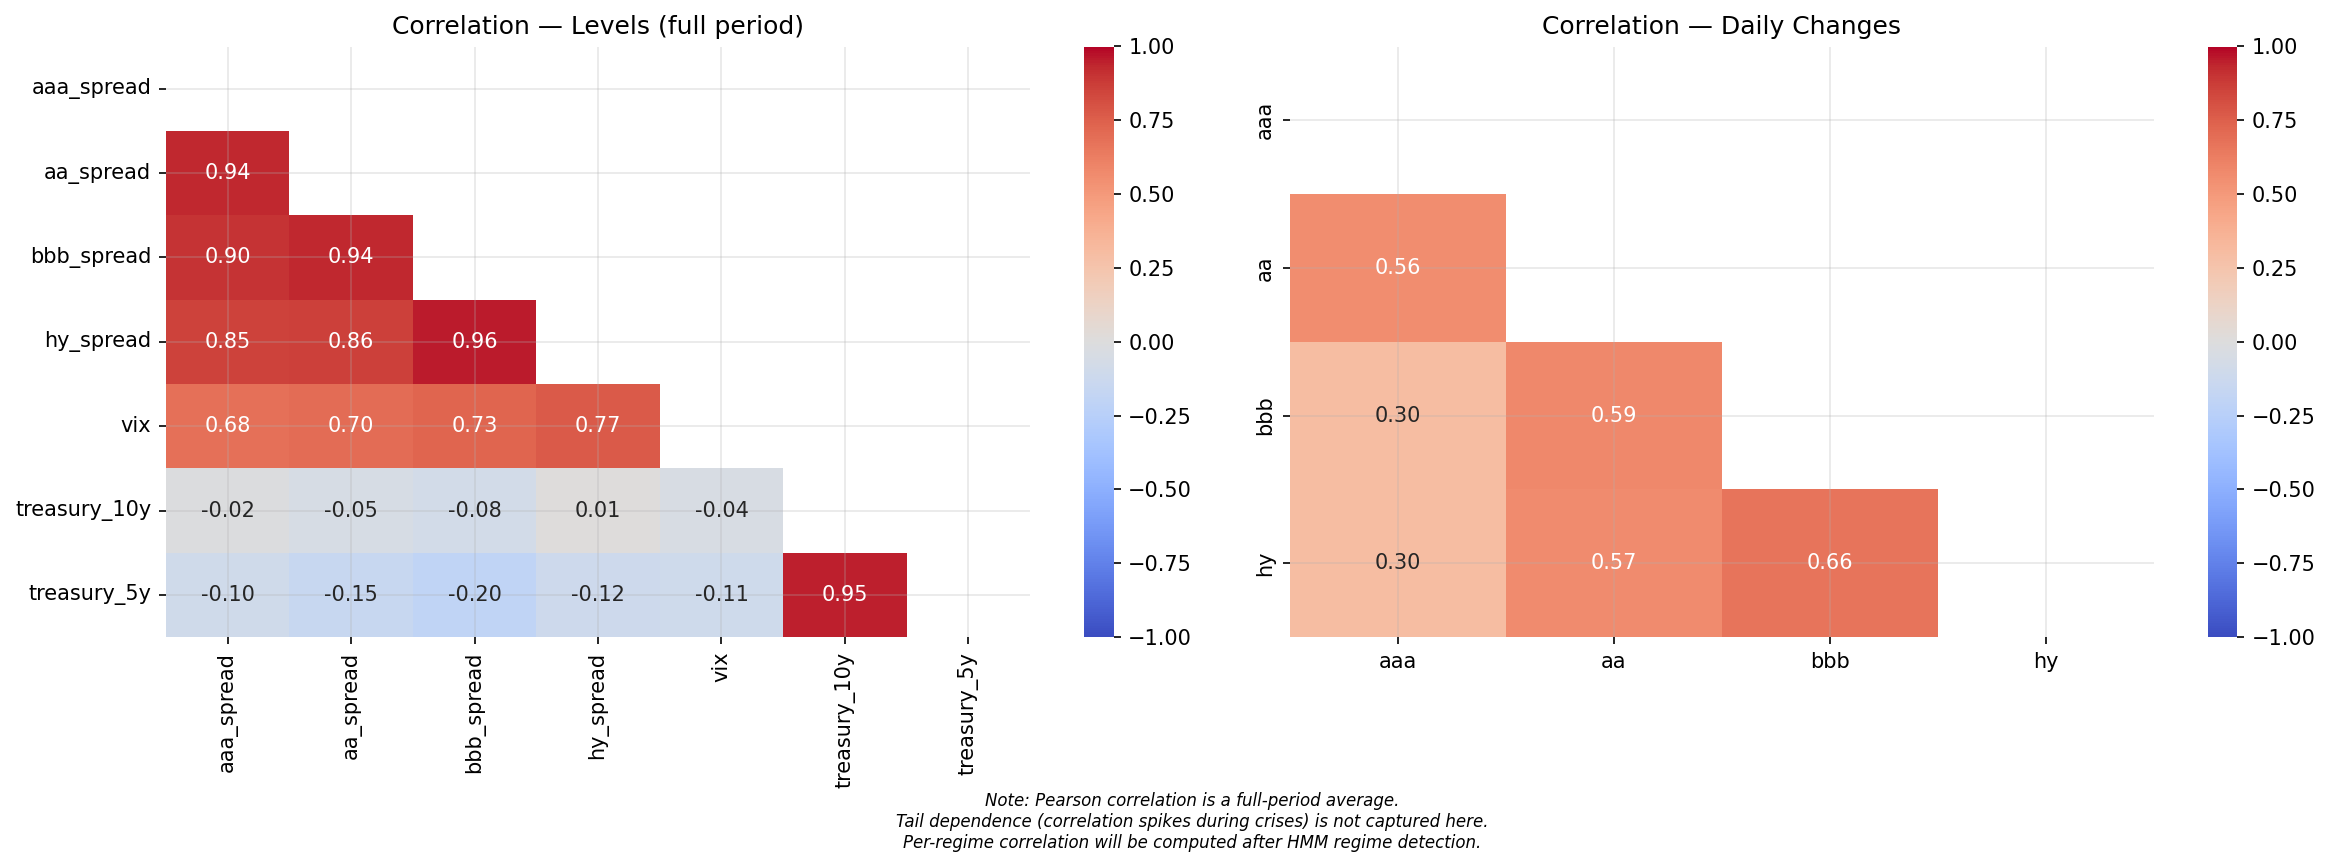

In [61]:
level_cols = [c for c in ["aaa_spread", "aa_spread", "bbb_spread", "hy_spread",
                           "vix", "treasury_10y", "treasury_5y"] if c in df.columns]
change_cols = [c for c in df.columns if c.endswith("_change_1d") and "ratio" not in c]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Levels
corr_levels = df[level_cols].corr()
mask = np.triu(np.ones_like(corr_levels, dtype=bool))
sns.heatmap(corr_levels, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Correlation — Levels (full period)")

# Changes
if change_cols:
    corr_changes = df[change_cols].corr()
    # Shorten column names for readability
    short_names = [c.replace("_spread_change_1d", "").replace("_change_1d", "")
                   for c in change_cols]
    corr_changes.index = short_names
    corr_changes.columns = short_names
    mask2 = np.triu(np.ones_like(corr_changes, dtype=bool))
    sns.heatmap(corr_changes, mask=mask2, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title("Correlation — Daily Changes")

fig.suptitle(
    "Note: Pearson correlation is a full-period average.\n"
    "Tail dependence (correlation spikes during crises) is not captured here.\n"
    "Per-regime correlation will be computed after HMM regime detection.",
    fontsize=8, style="italic", y=0.02,
)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

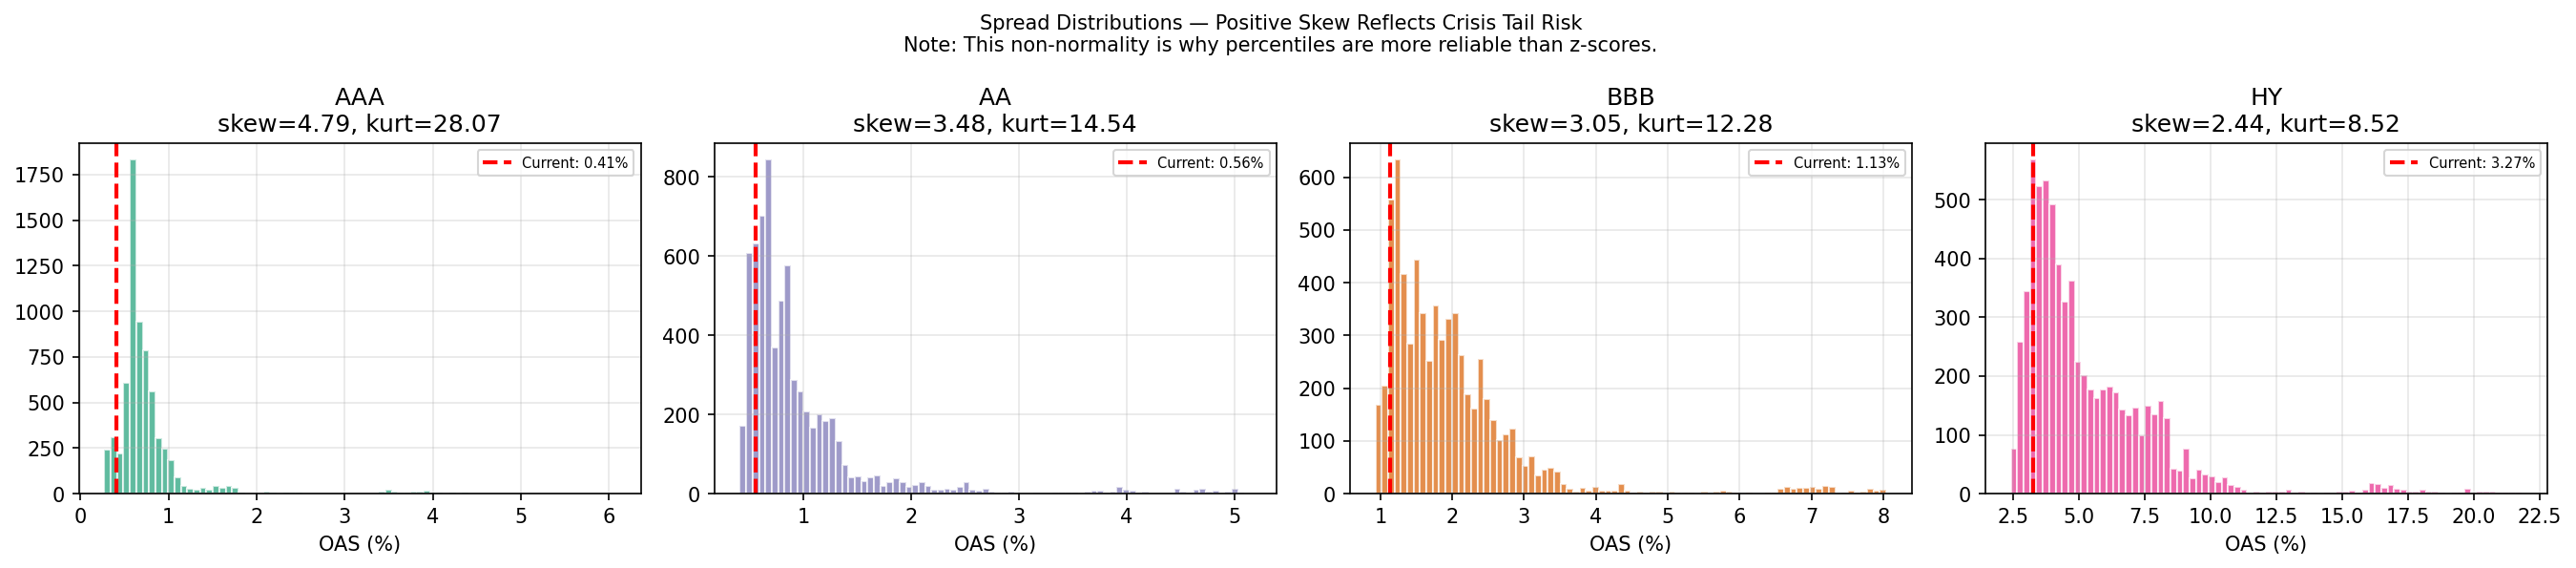

In [62]:
spread_cols = ["aaa_spread", "aa_spread", "bbb_spread", "hy_spread"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, spread_cols):
    data = df[col].dropna()
    current = data.iloc[-1]
    skew = data.skew()
    kurt = data.kurtosis()

    ax.hist(data, bins=80, alpha=0.7, color=COLORS[col], edgecolor="white")
    ax.axvline(current, color="red", linewidth=2, linestyle="--",
               label=f"Current: {current:.2f}%")
    ax.set_title(f"{col.replace('_spread','').upper()}\nskew={skew:.2f}, kurt={kurt:.2f}")
    ax.set_xlabel("OAS (%)")
    ax.legend(fontsize=7)

fig.suptitle(
    "Spread Distributions — Positive Skew Reflects Crisis Tail Risk\n"
    "Note: This non-normality is why percentiles are more reliable than z-scores.",
    fontsize=10,
)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "spread_distribution.png", bbox_inches="tight")
plt.show()